# 0. Preprocessing

## Mengimpor Library dan Membaca Dataset

In [ ]:
import pandas as pd

file_path = '/content/CAD alizadeh.xls'

df = pd.read_excel(file_path)

Di sel ini, kami mengimpor library pandas untuk memproses data, menentukan lokasi file dataset di Google Drive, lalu membaca file Excel tersebut ke dalam DataFrame df.

## Menampilkan Dataset


In [ ]:
df

,No,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,...,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
0,1,53,90,175,Male,29.387755,0,1,1,0,...,4.7,141,5700,39,52,261,50,0,N,Cad
1,2,67,70,157,Fmale,28.398718,0,1,0,0,...,4.7,156,7700,38,55,165,40,4,N,Cad
2,3,54,54,164,Male,20.077335,0,0,1,0,...,4.7,139,7400,38,60,230,40,2,mild,Cad
3,4,66,67,158,Fmale,26.838648,0,1,0,0,...,4.4,142,13000,18,72,742,55,0,Severe,Normal
4,5,50,87,153,Fmale,37.165193,0,1,0,0,...,4.0,140,9200,55,39,274,50,0,Severe,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,299,58,84,168,Male,29.761905,0,0,0,0,...,4.8,146,8500,34,58,251,45,0,N,Cad
299,300,55,64,152,Fmale,27.700831,0,0,0,0,...,4.0,139,11400,16,80,377,40,0,mild,Normal
300,301,48,77,160,Fmale,30.078125,0,1,0,0,...,4.0,140,9000,35,55,279,55,0,N,Normal
301,302,57,90,159,Fmale,35.599858,1,0,0,0,...,3.8,141,3800,48,40,208,55,0,N,Normal


Di sel ini, kami menampilkan DataFrame df untuk melihat isi data. Dataset memiliki 303 baris dan 56 kolom.

## Memeriksa Missing Values

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

No                       0
Age                      0
Weight                   0
Length                   0
Sex                      0
BMI                      0
DM                       0
HTN                      0
Current Smoker           0
EX-Smoker                0
FH                       0
Obesity                  0
CRF                      0
CVA                      0
Airway disease           0
Thyroid Disease          0
CHF                      0
DLP                      0
BP                       0
PR                       0
Edema                    0
Weak Peripheral Pulse    0
Lung rales               0
Systolic Murmur          0
Diastolic Murmur         0
Typical Chest Pain       0
Dyspnea                  0
Function Class           0
Atypical                 0
Nonanginal               0
Exertional CP            0
LowTH Ang                0
Q Wave                   0
St Elevation             0
St Depression            0
Tinversion               0
LVH                      0
P

Di sel ini, kami memeriksa nilai kosong di setiap kolom menggunakan df.isnull().sum() dan mencetak hasilnya. Hasilnya menunjukkan bahwa tidak ada nilai null pada dataset, sehingga data sudah lengkap.

## Mengubah Semua Kolom Menjadi Numerik

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_clean = df.copy()

categorical_cols = df_clean.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

df_clean

,No,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,...,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
0,1,53,90,175,1,29.387755,0,1,1,0,...,4.7,141,5700,39,52,261,50,0,1,0
1,2,67,70,157,0,28.398718,0,1,0,0,...,4.7,156,7700,38,55,165,40,4,1,0
2,3,54,54,164,1,20.077335,0,0,1,0,...,4.7,139,7400,38,60,230,40,2,3,0
3,4,66,67,158,0,26.838648,0,1,0,0,...,4.4,142,13000,18,72,742,55,0,2,1
4,5,50,87,153,0,37.165193,0,1,0,0,...,4.0,140,9200,55,39,274,50,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,299,58,84,168,1,29.761905,0,0,0,0,...,4.8,146,8500,34,58,251,45,0,1,0
299,300,55,64,152,0,27.700831,0,0,0,0,...,4.0,139,11400,16,80,377,40,0,3,1
300,301,48,77,160,0,30.078125,0,1,0,0,...,4.0,140,9000,35,55,279,55,0,1,1
301,302,57,90,159,0,35.599858,1,0,0,0,...,3.8,141,3800,48,40,208,55,0,1,1


Di sel ini, kami menyalin DataFrame df ke df_clean, lalu mengidentifikasi kolom bertipe object. Saya kemudian menggunakan LabelEncoder untuk mengubah kolom kategori menjadi angka, dan memastikan semuanya dikonversi ke tipe numerik. Hasil akhirnya terlihat di df_clean.








## Melakukan Normalisasi pada Masing-masing Kolom


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_normalized = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

df_normalized

,No,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,...,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
0,0.000000,0.410714,0.583333,0.729167,1.0,0.494721,0.0,1.0,1.0,0.0,...,0.472222,0.464286,0.139860,0.603774,0.350877,0.329149,0.777778,0.0,0.333333,0.0
1,0.003311,0.660714,0.305556,0.354167,0.0,0.451314,0.0,1.0,0.0,0.0,...,0.472222,1.000000,0.279720,0.584906,0.403509,0.195258,0.555556,1.0,0.333333,0.0
2,0.006623,0.428571,0.083333,0.500000,1.0,0.086105,0.0,0.0,1.0,0.0,...,0.472222,0.392857,0.258741,0.584906,0.491228,0.285914,0.555556,0.5,1.000000,0.0
3,0.009934,0.642857,0.263889,0.375000,0.0,0.382846,0.0,1.0,0.0,0.0,...,0.388889,0.500000,0.650350,0.207547,0.701754,1.000000,0.888889,0.0,0.666667,1.0
4,0.013245,0.357143,0.541667,0.270833,0.0,0.836058,0.0,1.0,0.0,0.0,...,0.277778,0.428571,0.384615,0.905660,0.122807,0.347280,0.777778,0.0,0.666667,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.986755,0.500000,0.500000,0.583333,1.0,0.511142,0.0,0.0,0.0,0.0,...,0.500000,0.642857,0.335664,0.509434,0.456140,0.315202,0.666667,0.0,0.333333,0.0
299,0.990066,0.446429,0.222222,0.250000,0.0,0.420685,0.0,0.0,0.0,0.0,...,0.277778,0.392857,0.538462,0.169811,0.842105,0.490934,0.555556,0.0,1.000000,1.0
300,0.993377,0.321429,0.402778,0.416667,0.0,0.525020,0.0,1.0,0.0,0.0,...,0.277778,0.428571,0.370629,0.528302,0.403509,0.354254,0.888889,0.0,0.333333,1.0
301,0.996689,0.482143,0.583333,0.395833,0.0,0.767358,1.0,0.0,0.0,0.0,...,0.222222,0.464286,0.006993,0.773585,0.140351,0.255230,0.888889,0.0,0.333333,1.0


Di sel ini, saya menggunakan library scikit-learn (tepatnya MinMaxScaler) untuk menormalkan setiap kolom di df_clean agar nilainya berada pada rentang 0 hingga 1. Hasil normalisasi saya simpan dalam df_normalized, lalu saya menampilkan hasilnya dalam bentuk dataframe.

# 1. Random Forest


## Membagi data test dan train


In [ ]:
from sklearn.model_selection import train_test_split

X = df_normalized.drop(columns=["Cath"])
y = df_normalized["Cath"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((242, 55), (61, 55), (242,), (61,))

Di sel ini, kami memisahkan kolom Cath sebagai target (y) dan kolom lainnya sebagai fitur (X), lalu menggunakan train_test_split untuk membagi data menjadi 80% data latih dan 20% data uji dengan random_state=42. Untuk info tambahan kami menampilkan ukuran DataFrame setelah pembagian.

## Melakukan Klasifikasi CAD dengan Random Forest


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

Di sel ini, kami mengimpor RandomForestClassifier dari sklearn.ensemble, kemudian membuat model Random Forest dengan 100 pohon keputusan (n_estimators=100) dan random state 42 agar hasil replikasi konsisten. Setelah itu, kami melatih model menggunakan data latih (X_train dan y_train), lalu melakukan prediksi terhadap data uji (X_test) dan menyimpan hasilnya di y_pred_rf.

## Mengevaluasi Performa Model Random Forest

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label=1)
recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)
specificity_rf = recall_score(y_test, y_pred_rf, pos_label=0)
false_positive_rate_rf = 1 - specificity_rf
false_negative_rate_rf = 1 - recall_rf

print("Confusion Matrix (Random Forest):")
print(conf_matrix_rf)
print(f"\nAkurasi: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall (Sensitivity): {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"Specificity (True Negative Rate): {specificity_rf:.4f}")
print(f"False Positive Rate: {false_positive_rate_rf:.4f}")
print(f"False Negative Rate: {false_negative_rate_rf:.4f}")


Confusion Matrix (Random Forest):
[[41  2]
 [ 7 11]]

Akurasi: 0.8525
Precision: 0.8462
Recall (Sensitivity): 0.6111
F1-Score: 0.7097
Specificity (True Negative Rate): 0.9535
False Positive Rate: 0.0465
False Negative Rate: 0.3889


Di sel ini kami menggunakan library sklearn.metrics untuk mengevaluasi performa model Random Forest. Kami menghitung metrik seperti akurasi, presisi, recall (sensitivitas), F1-score, spesifisitas, serta false positive dan false negative rate. Dari hasil yang diperoleh, model menunjukkan performa cukup baik dengan akurasi sebesar 85,25% dan presisi 84,62%. Namun, recall hanya 61,11% yang berarti masih ada kasus positif yang tidak terdeteksi. Di sisi lain, spesifisitas cukup tinggi (95,35%), menandakan model cukup andal dalam mengenali kasus negatif.

#2. K-Means

## Normalisasi Fitur

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# --- 2. Cek dan Konversi Label 'Cath' ke Angka ---
print("Sebelum mapping:", df['Cath'].unique())
df['Cath'] = df['Cath'].map({'Normal': 0, 'Cad': 1})
df = df.dropna(subset=['Cath'])  # Drop baris dengan nilai Cath tak dikenal
df['Cath'] = df['Cath'].astype(int)
print("Setelah mapping:", df['Cath'].unique())

# --- 3. Pilih Fitur untuk K-Means (tanpa 'Cath') ---
features = ['Age', 'BMI', 'LDL', 'HDL', 'FBS', 'TG', 'HTN', 'DM']
X_kmeans = df[features]
y_true = df['Cath'].values  # Label asli hanya untuk evaluasi

# --- 4. Normalisasi ---
scaler = MinMaxScaler()
X_kmeans_norm = scaler.fit_transform(X_kmeans)

Sebelum mapping: ['Cad' 'Normal']
Setelah mapping: [1 0]


Kami memilih fitur numerik utama yang merepresentasikan profil metabolik dan risiko kardiovaskular pasien. Semua fitur dinormalisasi menggunakan MinMaxScaler agar skala antar fitur seragam dan tidak mendistorsi hasil klastering.

##  Menentukan Jumlah Klaster (Elbow Method Manual)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

distortions = []
K_range = range(1, 7)
for k in K_range:
    centroids = X_kmeans_norm[np.random.choice(range(X_kmeans_norm.shape[0]), k, replace=False)]
    for _ in range(10):
        clusters = [[] for _ in range(k)]
        for point in X_kmeans_norm:
            dists = [euclidean(point, c) for c in centroids]
            clusters[np.argmin(dists)].append(point)
        centroids = np.array([np.mean(cluster, axis=0) if len(cluster) > 0 else centroids[i] for i, cluster in enumerate(clusters)])
    distortion = sum([
        euclidean(point, centroids[np.argmin([euclidean(point, c) for c in centroids])])
        for point in X_kmeans_norm
    ])
    distortions.append(distortion)

Kami melakukan perhitungan Elbow Method secara manual untuk menentukan jumlah klaster optimal dengan menghitung nilai distortion pada berbagai jumlah klaster.

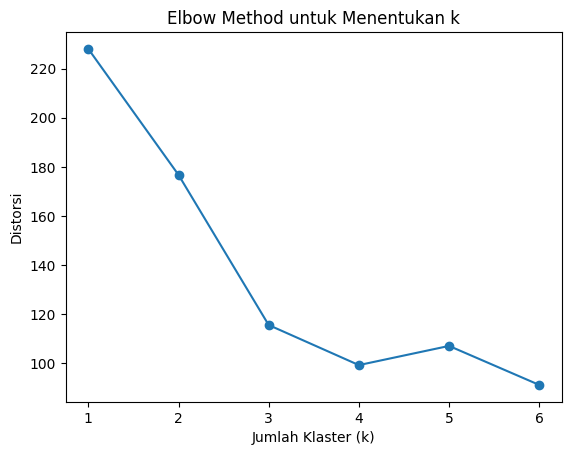

In [ ]:
# Plot Elbow
plt.plot(K_range, distortions, marker='o')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Distorsi')
plt.title('Elbow Method untuk Menentukan k')
plt.show()

## K-Means Clustering (Tanpa Library)

In [ ]:
k = 3
centroids = X_kmeans_norm[np.random.choice(range(X_kmeans_norm.shape[0]), k, replace=False)]
for _ in range(20):
    clusters = [[] for _ in range(k)]
    for point in X_kmeans_norm:
        dists = [euclidean(point, c) for c in centroids]
        clusters[np.argmin(dists)].append(point)
    centroids = np.array([np.mean(cluster, axis=0) if len(cluster) > 0 else centroids[i] for i, cluster in enumerate(clusters)])

# Assign labels
labels = np.zeros(len(X_kmeans_norm))
for idx, point in enumerate(X_kmeans_norm):
    dists = [euclidean(point, c) for c in centroids]
    labels[idx] = np.argmin(dists)

Kami membangun algoritma K-Means dari awal tanpa library, mulai dari inisialisasi centroid, penugasan anggota klaster, update centroid, hingga mendapatkan label klaster untuk setiap data.

## Evaluasi Kualitas Klustering

In [ ]:
from sklearn.metrics import silhouette_score

# --- 7. Evaluasi Clustering (Unsupervised) ---
sil_score = silhouette_score(X_kmeans_norm, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.5242195094058903


Kami mengevaluasi kualitas hasil klastering menggunakan silhouette score untuk mengukur seberapa baik objek berada pada klaster yang sesuai.

In [ ]:
from scipy.stats import mode

# --- 8. Mapping Klaster ke Label `Cath` dan Hitung Akurasi (opsional) ---
mapped_labels = np.zeros_like(labels)
for i in range(k):
    mask = (labels == i)
    if np.sum(mask) == 0:
        continue
    mapped_labels[mask] = mode(y_true[mask])[0]

accuracy = accuracy_score(y_true, mapped_labels)
print("Mapped Accuracy terhadap Cath:", accuracy)

Mapped Accuracy terhadap Cath: 0.7128712871287128


In [ ]:
# Data dummy (ganti nilainya sesuai keinginan)
dummy_input = pd.DataFrame([{
    'Age': 58,
    'BMI': 27.5,
    'LDL': 150,
    'HDL': 40,
    'FBS': 120,
    'TG': 180,
    'HTN': 1,
    'DM': 0
}])

# Normalisasi dummy input pakai scaler yang sama
dummy_input_scaled = scaler.transform(dummy_input)

# Hitung jarak ke centroid
dists = [euclidean(dummy_input_scaled[0], c) for c in centroids]
assigned_cluster = np.argmin(dists)

# Mapping klaster ke label berdasarkan mayoritas isi
cluster_label = mode(y_true[labels == assigned_cluster], keepdims=True).mode[0]
label_name = "CAD" if cluster_label == 1 else "Normal"

print(f"Dummy ini masuk ke klaster: {assigned_cluster}")
print(f"Mayoritas isi klaster ini: {label_name}")

Dummy ini masuk ke klaster: 1
Mayoritas isi klaster ini: CAD


In [ ]:
dummy_input = pd.DataFrame([{
    'Age': 40,
    'BMI': 21.5,
    'LDL': 90,
    'HDL': 65,
    'FBS': 85,
    'TG': 100,
    'HTN': 0,
    'DM': 0
}])

# Normalisasi dummy input pakai scaler yang sama
dummy_input_scaled = scaler.transform(dummy_input)

# Hitung jarak ke centroid
dists = [euclidean(dummy_input_scaled[0], c) for c in centroids]
assigned_cluster = np.argmin(dists)

# Mapping klaster ke label berdasarkan mayoritas isi
cluster_label = mode(y_true[labels == assigned_cluster], keepdims=True).mode[0]
label_name = "CAD" if cluster_label == 1 else "Normal"

print(f"Dummy ini masuk ke klaster: {assigned_cluster}")
print(f"Mayoritas isi klaster ini: {label_name}")

Dummy ini masuk ke klaster: 2
Mayoritas isi klaster ini: Normal
